In [53]:
import ProcessEmbryo as PrEm
print(PrEm.__version__)

25.06.04


In [54]:
loaded_stack = PrEm.get_stack(r'C:\Users\denis\Desktop\Posfai lab\Alana_fucci\260206_stack2\processed.stack')

Text(0.5, 1.0, '260206_stack2')

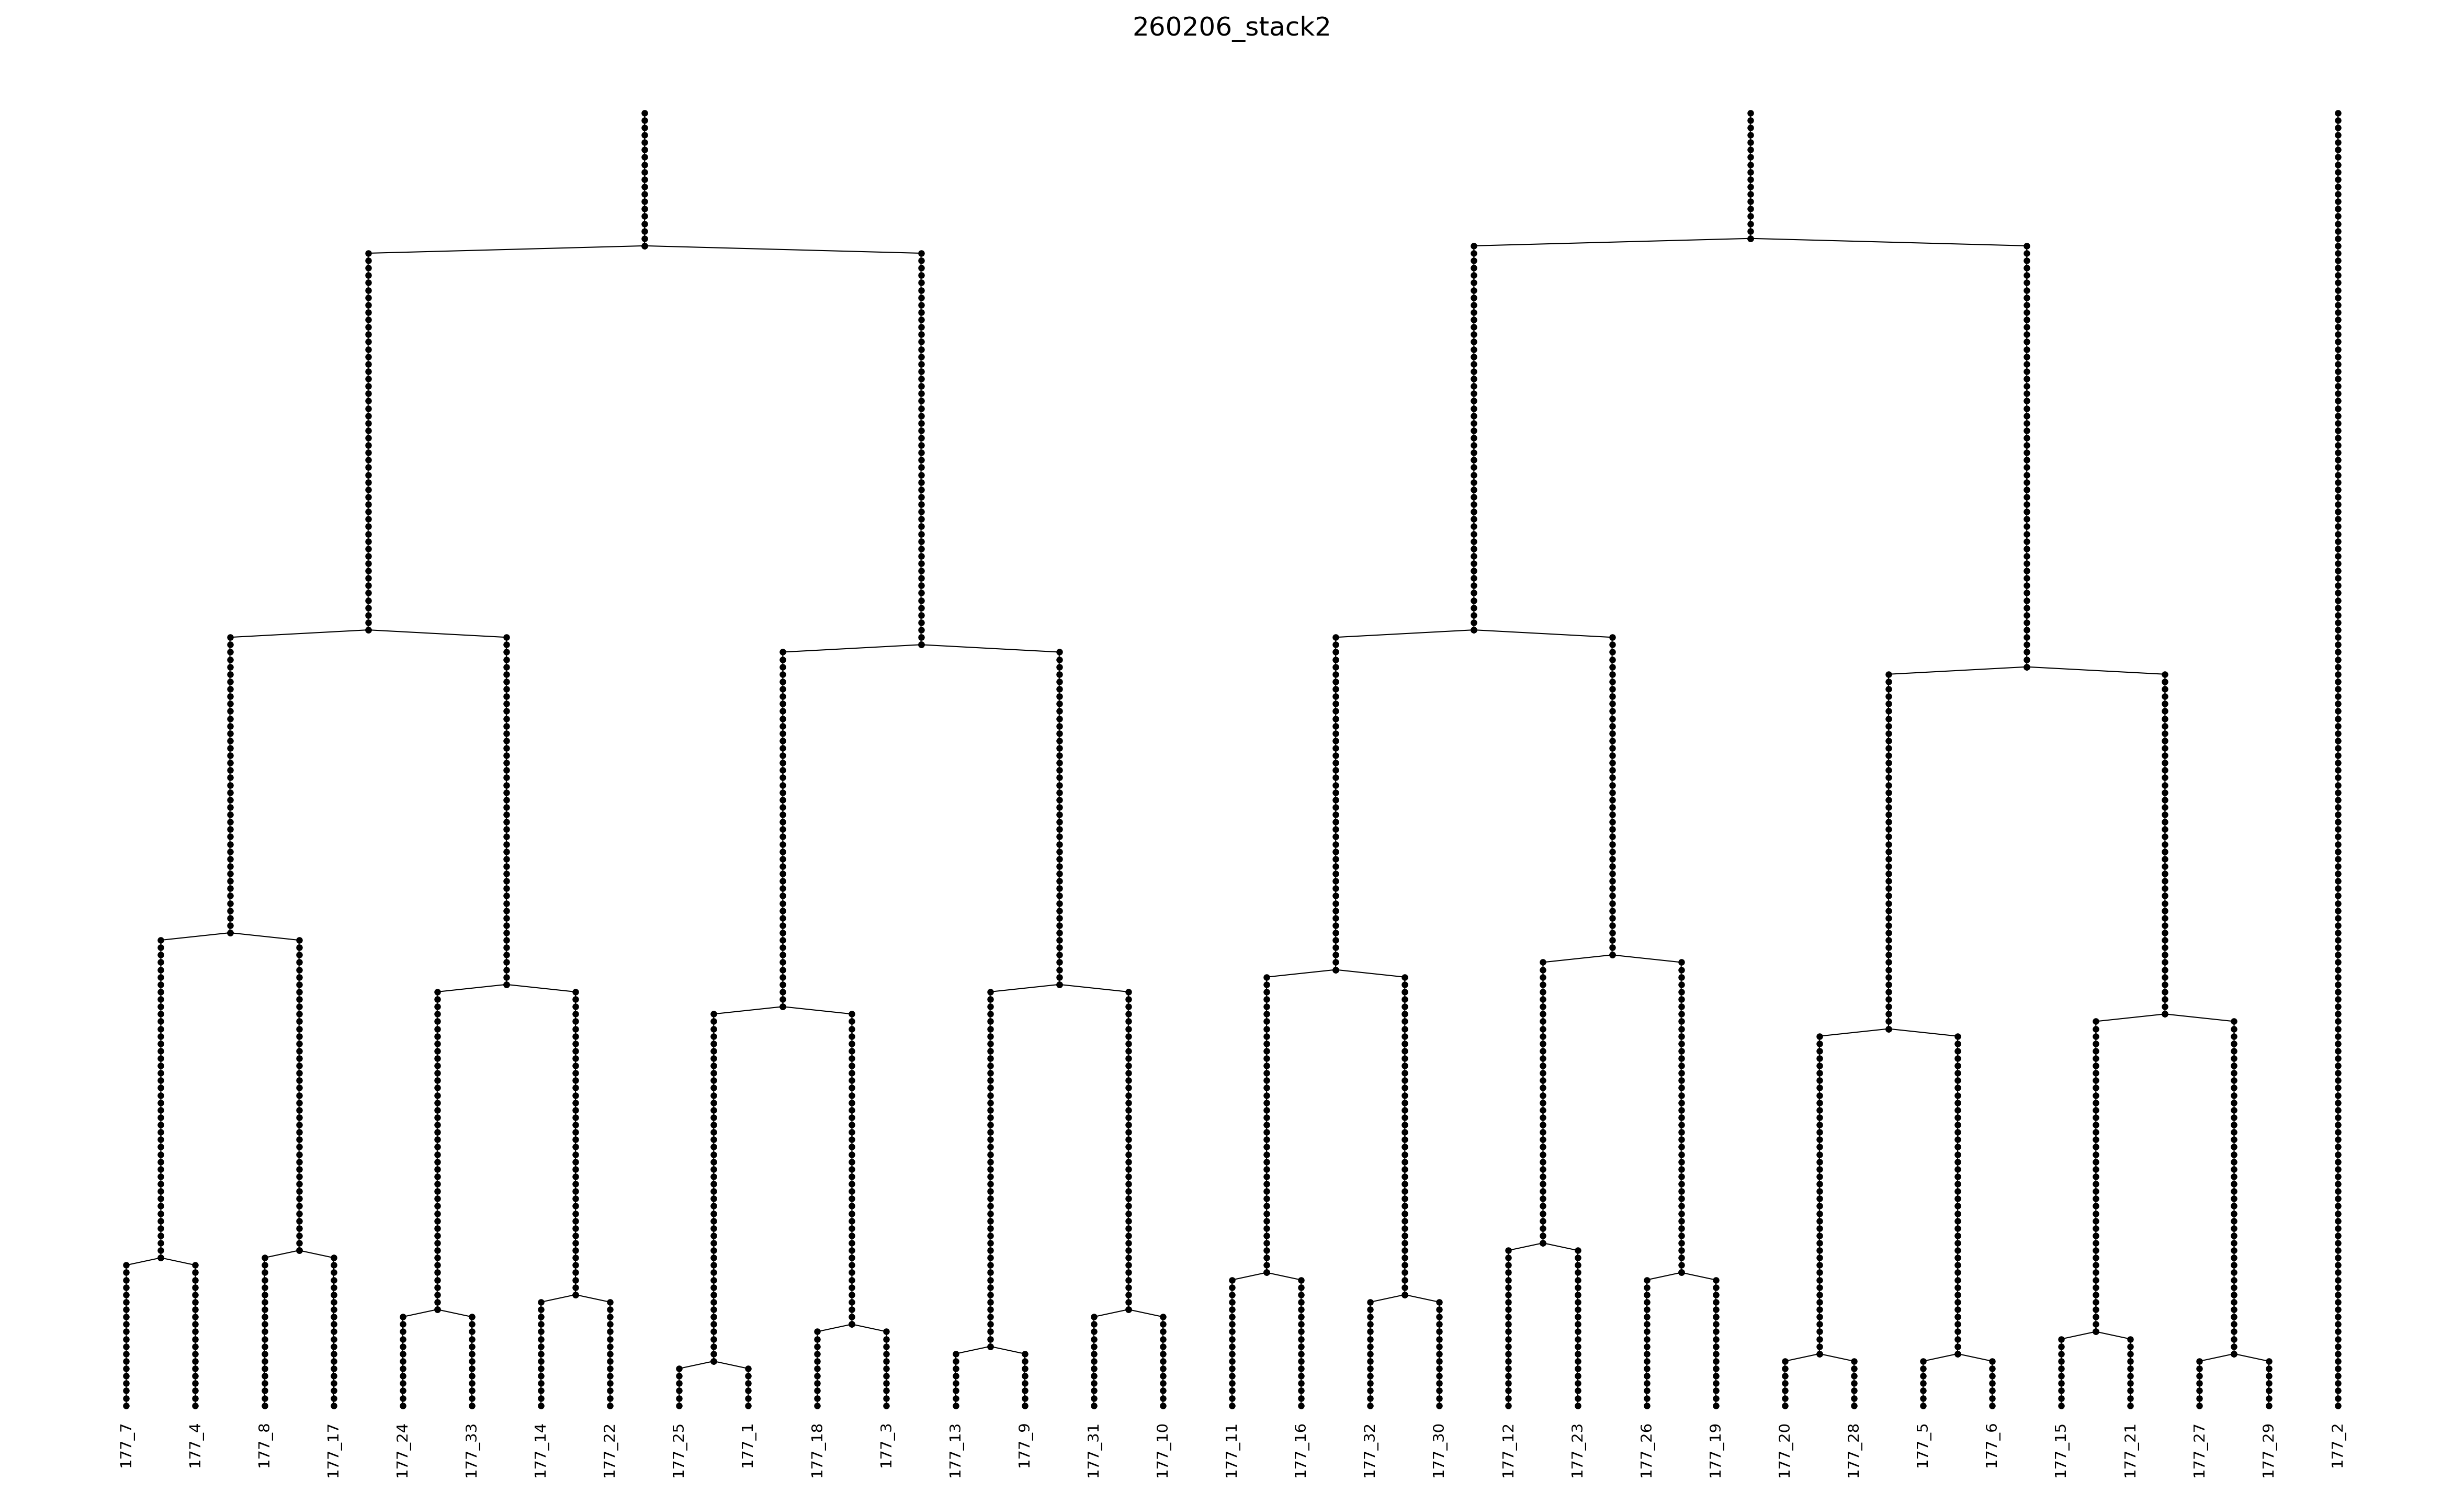

In [55]:
spacing = 5
space_shrinking = 2
padding = 10
encounter = []
encounter_x = []
last_x = 0

plt.figure(figsize=(20, 12), dpi=300)

for cell_i in range(len(loaded_stack[0])):
    cur_x = last_x
    stop_here = False
    just_updated = False
    skeweness = 'left'
    shrink_counter = 0

    cell_plot_x = []
    cell_plot_y = []

    cell = loaded_stack[0][cell_i]

    for i in range(1, len(cell[1])):

        cell_ID = [cell[1][len(cell[1])-i][0], cell[1][len(cell[1])-i][1]]
        if cell_ID in cell[2]:
            if cell_ID in encounter:
                cur_x = encounter_x[encounter.index(cell_ID)][0]
                cell_plot_x.append(cur_x)
                cell_plot_y.append(encounter[encounter.index(cell_ID)][0])

                space_factor = encounter_x[encounter.index(cell_ID)][2]
                last_cur_x = cur_x

                if encounter_x[encounter.index(cell_ID)][1] == 'left':
                    skeweness = 'right'
                    skew_factor = 1
                else:
                    skew_factor = -1
                
                for j in range(2, len(cell_plot_x)+1):
                    #print(cell_plot_y[len(cell_plot_x)-j], cell_plot_y[len(cell_plot_x)-j])
                    tmp_ID = [cell[1][len(cell[1])-i+j-1][0], cell[1][len(cell[1])-i+j-1][1]]
                    #print(tmp_ID)
                    cell_plot_x[len(cell_plot_x)-j] = last_cur_x + skew_factor * space_factor
                    if tmp_ID in cell[2]:
                        last_cur_x = cell_plot_x[len(cell_plot_x)-j]
                        space_factor = space_factor / 2
                    if tmp_ID in encounter:
                        encounter_x[encounter.index(tmp_ID)][0] = cell_plot_x[len(cell_plot_x)-j]
                        encounter_x[encounter.index(tmp_ID)][1] = skeweness
                        encounter_x[encounter.index(tmp_ID)][2] = space_factor

                stop_here = True
            else:
                cur_x += spacing * (space_shrinking ** shrink_counter)
                encounter.append(cell_ID)
                encounter_x.append([cur_x, skeweness, spacing * (space_shrinking ** shrink_counter)])
                shrink_counter += 1

        if stop_here:
            break
        
        cell_plot_x.append(cur_x)
        cell_plot_y.append(cell[1][len(cell[1])-i][0])

    plt.plot(cell_plot_x, cell_plot_y, marker='o', markersize=2, linewidth=0.5, color='black')
    plt.text(cell_plot_x[0], cell_plot_y[0] + 2, str(cell[1][len(cell[1])-1][0]) + '_' + str(cell[1][len(cell[1])-1][1]), rotation='vertical',
        horizontalalignment='center', verticalalignment='top', fontsize = 7)
    
    temp_last_x = max(cell_plot_x)
    if temp_last_x > last_x:
        last_x = (temp_last_x - last_x) * 2 + last_x + padding

plt.axis('off')
plt.gca().invert_yaxis()
plt.title('260206_stack2')